# Aula Semana 05: Inferência Estatística e Testes de Hipóteses

## 1. Fundamentos da Inferência Estatística e Testes de Hipóteses

Na Ciência de Dados, frequentemente precisamos tomar decisões sobre uma **população inteira** (ex: todos os clientes de uma fintech, todos os lotes de produção de uma fábrica) a partir de uma **amostra limitada de dados**.

A **Inferência Estatística** fornece a fundamentação matemática rigorosa para tirar conclusões sobre a população a partir de dados amostrais, avaliando o grau de incerteza associado a essas decisões.

---

### 1.1 O Framework dos Testes de Hipóteses

Um **Teste de Hipóteses** é uma regra de decisão estatística que permite rejeitar ou não rejeitar uma afirmação sobre um parâmetro populacional a partir de evidências amostrais.

Todo teste estatístico parte da formulação de duas hipóteses mutuamente exclusivas:

* **Hipótese Nula ($H_0$)**: Representa a afirmação padrão, o status quo ou a hipótese de "não efeito" / "não diferença" / "não associação". Exemplo: *"A média de temperatura do processo A é igual à do processo B"* ou *"A variável segue uma distribuição normal"*.
* **Hipótese Alternativa ($H_1$ ou $H_a$)**: Representa a hipótese do pesquisador, a afirmação de que existe um efeito, uma diferença significativa ou um desvio da norma. Exemplo: *"A média de temperatura do processo A é diferente da do processo B"*.

```text
┌─────────────────────────────────────────────────────────────────────────┐
│                     ESTRUTURA DE UM TESTE DE HIPÓTESES                  │
│                                                                         │
│   1. Formular H₀ (Status Quo) vs. H₁ (Hipótese de Interesse)           │
│   2. Fixar o Nível de Significância α (geralmente 0.05 / 5%)            │
│   3. Calcular a Estatística de Teste a partir dos dados amostrais       │
│   4. Determinar o p-valor (p-value)                                     │
│   5. Decisão:                                                           │
│        • Se p-valor ≤ α  ==> REJEITA-SE H₀ (Evidência a favor de H₁)    │
│        • Se p-valor > α  ==> NÃO SE REJEITA H₀                          │
└─────────────────────────────────────────────────────────────────────────┘
```

--- 

### 1.2 O Conceito Crítico de p-valor (*p-value*)

O **p-valor** é a probabilidade de obter uma estatística de teste tão extrema quanto (ou mais extrema que) a observada na amostra, **assumindo que a hipótese nula ($H_0$) seja verdadeira**.

* **p-valor pequeno ($p \le \alpha$)**: Indica que o evento observado é extremamente improvável sob a suposição de $H_0$. Logo, temos evidência estatística suficiente para **rejeitar $H_0$**.
* **p-valor grande ($p > \alpha$)**: Indica que os dados observados são compatíveis com $H_0$. Não temos evidência suficiente para rejeitar a hipótese nula.

> ⚠️ **Cuidado didático**: Dizer que "não rejeitamos $H_0$" NÃO é o mesmo que provar que $H_0$ é verdadeira. Significa apenas que não temos evidência empírica suficiente contra ela com a amostra atual.

--- 

### 1.3 Erros de Decisão Estatística

Ao tomar uma decisão estatística baseada em amostras, estamos sujeitos a dois tipos de erros:

| Realidade da População | Decisão: Não Rejeitar $H_0$ | Decisão: Rejeitar $H_0$ |
| :--- | :--- | :--- |
| **$H_0$ é Verdadeira** | Decisão Correta ($1 - \alpha$) | **Erro Tipo I ($\alpha$)** - Falso Positivo Estatístico |
| **$H_0$ é Falsa** | **Erro Tipo II ($\beta$)** - Falso Negativo Estatístico | Decisão Correta - **Poder do Teste ($1 - \beta$)** |

* **Erro Tipo I ($\alpha$)**: Ocorre quando rejeitamos $H_0$, mas $H_0$ era verdadeira. O nível de significância $\alpha$ (geralmente 5%) é a tolerância máxima a esse erro.
* **Erro Tipo II ($\beta$)**: Ocorre quando não rejeitamos $H_0$, mas $H_0$ era falsa (falhamos em detectar um efeito real).
* **Poder Estatístico ($1 - \beta$)**: A capacidade do teste de identificar corretamente um efeito real. Aumenta com o tamanho da amostra ($n$).


--- 
## 2. Avaliação de Admissibilidade: Testes de Normalidade

Muitos testes estatísticos clássicos (como o teste t de Student e ANOVA) e algoritmos de Machine Learning assumem que os dados contínuos seguem uma **Distribuição Normal (Gaussiana)**.

Antes de aplicar estes métodos, devemos executar **Testes de Normalidade** para validar se essa premissa é atendida.

### Hipóteses nos Testes de Normalidade:
* **$H_0$ (Hipótese Nula)**: Os dados seguem uma Distribuição Normal ($p > 0.05$).
* **$H_1$ (Hipótese Alternativa)**: Os dados NÃO seguem uma Distribuição Normal ($p \le 0.05$).

---

### 2.1 Função de Distribuição Acumulada: Teórica (CDF) vs. Empírica (ECDF)

Para compreender como testes de aderência não-paramétricos (como **Kolmogorov-Smirnov**) funcionam, é fundamental dominar o conceito de **Distribuição Acumulada**:

#### A. Distribuição Acumulada Teórica Normal (CDF - *Cumulative Distribution Function*)
Define a probabilidade acumulada teórica de que uma variável aleatória contínua $X$ seja menor ou igual a um valor $x$, sob a suposição de uma distribuição Normal perfeita $N(\mu, \sigma^2)$:

$$F(x) = P(X \le x) = \frac{1}{\sigma \sqrt{2\pi}} \int_{-\infty}^{x} e^{-\frac{(t-\mu)^2}{2\sigma^2}} dt$$

A curva da CDF teórica é suave, contínua e possui um formato sigmoidal característico em "S", variando suavemente de 0 (0%) a 1 (100%).

#### B. Função de Distribuição Acumulada Empírica (ECDF - *Empirical Cumulative Distribution Function*)
Representa a proporção acumulada real observada em uma **amostra de dados coletada da realidade**. Para uma amostra de tamanho $n$ ordenada $x_1 \le x_2 \le \dots \le x_n$, a ECDF é definida como:

$$F_n(x) = \frac{\text{Número de observações na amostra } \le x}{n} = \frac{1}{n} \sum_{i=1}^{n} \mathbb{I}(x_i \le x)$$

A ECDF é uma **função em degraus** (*step function*), onde cada observação da amostra adiciona um degrau vertical de altura $1/n$.

#### C. A Estatística de Teste Kolmogorov-Smirnov ($D$)
O teste Kolmogorov-Smirnov calcula a **distância vertical máxima ($D$)** entre a curva acumulada empírica da amostra $F_n(x)$ e a curva acumulada teórica esperada $F(x)$:

$$D = \sup_{x} |F_n(x) - F(x)|$$

* Se a distância $D$ for pequena, a curva empírica segue de perto a teórica ($p > 0.05 \implies$ Mantém-se $H_0$).
* Se a distância $D$ for grande, há evidência estatística de desvio de normalidade ($p \le 0.05 \implies$ Rejeita-se $H_0$).

---

### 2.2 Principais Testes de Normalidade em Ciência de Dados

#### 1. Teste de Shapiro-Wilk (`scipy.stats.shapiro`)
* **Descrição**: Amplamente considerado um dos testes formais **mais poderosos** para avaliar normalidade.
* **Recomendação**: Ideal para amostras de tamanho pequeno a médio ($n < 5.000$). Para amostras extremamente grandes, tende a detectar desvios minúsculos e rejeitar $H_0$ facilmente.

#### 2. Teste de Kolmogorov-Smirnov (`scipy.stats.kstest` ou `lilliefors`)
* **Descrição**: Teste não-paramétrico que compara a ECDF $F_n(x)$ com a CDF Teórica $F(x)$.
* **Recomendação**: Muito utilizado para amostras maiores, sendo sensível a diferenças no centro da distribuição.

#### 3. Teste de Anderson-Darling (`scipy.stats.anderson`)
* **Descrição**: Uma modificação aperfeiçoada do teste Kolmogorov-Smirnov que atribui **maior peso às caudas da distribuição**.
* **Recomendação**: Crucial em finanças, risco de crédito e manutenção preditiva industrial, onde o comportamento das caudas (valores extremos / outliers) é mais importante que o centro da distribuição.

#### 4. Avaliação Visual: Q-Q Plot (Quantile-Quantile Plot) e Curvas ECDF vs. CDF
* **Q-Q Plot**: Plota os quantis observados contra os quantis teóricos normais (linha de 45°).
* **ECDF vs. CDF**: Plota os degraus da amostra contra a curva suave em S da distribuição normal.


--- 
## 3. Testes para Variáveis Categóricas: Teste Qui-Quadrado ($\chi^2$)

Enquanto os testes de normalidade focam em variáveis numéricas contínuas, o **Teste Qui-Quadrado ($\chi^2$)** é a ferramenta fundamental para analisar **variáveis categóricas / qualitativas**.

--- 

### 3.1 Teste Qui-Quadrado de Independência (`scipy.stats.chi2_contingency`)

Avalia se existe **associação estatisticamente significativa** entre duas variáveis categóricas (ou se elas são independentes).

* **$H_0$ (Independência)**: As duas variáveis são independentes (não há associação entre elas). Exemplo: *"O turno de trabalho não influencia a taxa de peças defeituosas"*.
* **$H_1$ (Dependência)**: Existe associação estatística entre as duas variáveis. Exemplo: *"O turno de trabalho influencia a taxa de peças defeituosas"*.

#### Cálculo da Estatística $\chi^2$:
A estatística compara as **Frequências Observadas ($O_{ij}$)** na tabela de contingência com as **Frequências Esperadas ($E_{ij}$)** sob a suposição de independência:

$$\chi^2 = \sum_{i=1}^{r} \sum_{j=1}^{c} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$$

Onde a frequência esperada $E_{ij}$ para a célula $(i,j)$ é dada por:

$$E_{ij} = \frac{\text{Total da Linha } i \times \text{Total da Coluna } j}{\text{Total Geral de Amostras}}$$

--- 

### 3.2 Teste Qui-Quadrado de Aderência / Goodness-of-Fit (`scipy.stats.chisquare`)

Avalia se a distribuição de frequências observada em uma única variável categórica se ajusta a uma distribuição teórica ou histórica esperada (ex: se as vendas ocorrem de forma uniforme entre os dias da semana).


In [5]:
# =============================================================================
# ETAPA 1: Importação de Bibliotecas e Carga dos Dados de Usinagem
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import os

import warnings
warnings.filterwarnings('ignore')
from IPython.display import display

# Configuração estética dos gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.size'] = 11
np.random.seed(42)

# Carrega o dataset de Usinagem Industrial da pasta materiais
csv_path = r"../materiais/CRISP_DM_Random_Forest_Usinagem_Qualidade.csv"

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(f"Dataset de Usinagem carregado com sucesso: {df.shape[0]} linhas e {df.shape[1]} colunas.")
else:
    print("Gerando base sintética local com as colunas padronizadas do CSV...")
    n = 3000
    df = pd.DataFrame({
        'peca_id': [f"PEC-{80000 + i}" for i in range(n)],
        'tipo_maquina': np.random.choice(['Torno_CNC', 'Fresadora', 'Centro_Usinagem'], n),
        'material_peca': np.random.choice(['Aco_Carbono', 'Aluminio', 'Aco_Inox'], n),
        'fluido_corte': np.random.choice(['Soluvel', 'Sintetico', 'Seco'], n),
        'turno_operacao': np.random.choice(['Turno_1', 'Turno_2', 'Turno_3'], n, p=[0.4, 0.35, 0.25]),
        'rotacao_rpm': np.random.normal(3200, 450, n),
        'avancao_mm_min': np.random.normal(250, 50, n),
        'profundidade_corte_mm': np.random.uniform(0.5, 4.5, n),
        'desgaste_ferramenta_um': np.random.exponential(35, n) + 5.0,
        'temperatura_mancal_c': np.random.normal(65, 12, n),
        'pressao_hidraulica_bar': np.random.normal(120, 15, n),
        'tempo_ciclo_robo_seg': np.random.normal(45, 8, n),
        'dias_desde_calibracao': np.random.randint(1, 180, n),
        'ruido_sensor_vibracao_hz': np.random.normal(0, 15, n),
        'codigo_lote_materia_prima': np.random.randint(1000, 9999, n),
        'clp_ip_hash': [f"CLP-{hex(100000 + i)[2:].upper()}" for i in range(n)],
        'peca_defeituosa': np.random.choice([0, 1], n, p=[0.82, 0.18])
    })

display(df.head())


Dataset de Usinagem carregado com sucesso: 8000 linhas e 17 colunas.


,peca_id,tipo_maquina,material_peca,fluido_corte,turno_operacao,rotacao_rpm,avancao_mm_min,profundidade_corte_mm,desgaste_ferramenta_um,temperatura_mancal_c,pressao_hidraulica_bar,tempo_ciclo_robo_seg,dias_desde_calibracao,ruido_sensor_vibracao_hz,codigo_lote_materia_prima,clp_ip_hash,peca_defeituosa
0,PEC-80000,TORNO_CNC,Aco_Carbono,Soluvel,Turno_2,3500.5,235.2,1.82,5.3,51.9,117.8,34.3,44,-10.77,1784,CLP-E30F6,1
1,PEC-80001,Celula_Robotica,Aluminio,Soluvel,Turno_2,2923.3,276.8,0.92,11.3,72.5,111.7,44.4,122,17.66,9106,CLP-AA648,1
2,PEC-80002,Fresadora,Aco_Inox,Soluvel,Turno_1,3102.2,279.8,2.24,163.7,76.5,127.0,38.9,161,1.57,2330,CLP-88F27,1
3,PEC-80003,torno_cnc,Latao,Soluvel,Turno_3,3565.6,279.2,3.06,56.2,74.5,122.7,41.9,14,-3.19,1025,CLP-A2F77,1
4,PEC-80004,Torno_CNC,Aluminio,Seco,Turno_3,3989.3,318.6,2.61,38.4,76.6,128.8,41.5,18,-6.37,9767,CLP-E04E5,1


   AVALIAÇÃO DE NORMALIDADE DA VARIÁVEL: 'rotacao_rpm (Rotação Spindle)' (n = 7586)
[1] Shapiro-Wilk     : Estatística = 0.99915 | p-valor = 4.86343e-01 | Decisão: NÃO REJEITA H0 (Normal)
[2] Kolmogorov-Smir. : Distância D = 0.00782 | p-valor = 7.39102e-01 | Decisão: NÃO REJEITA H0 (Normal)
[3] Anderson-Darling : Estatística = 0.31699 | Crítico (5%) = 0.752 | Decisão: NÃO REJEITA H0 (Normal)
---------------------------------------------------------------------------


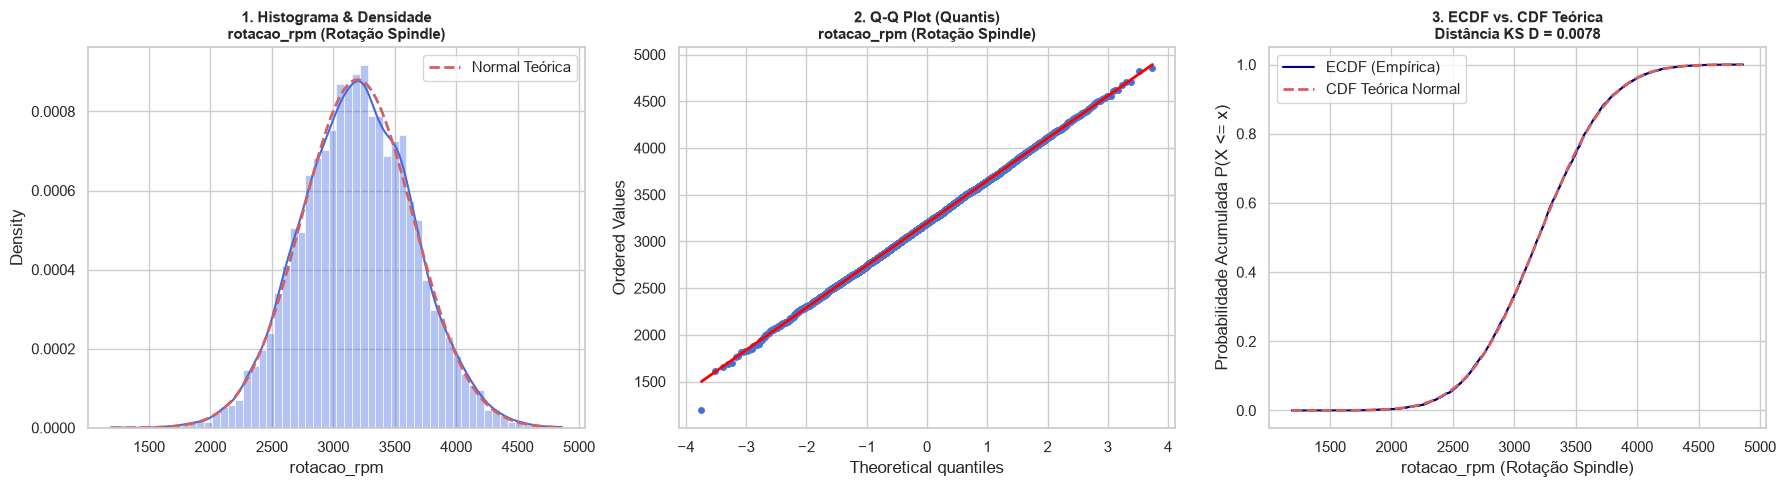

KeyError: 'vibracao_mm_s'

In [ ]:
# =============================================================================
# ETAPA 2: Testes de Normalidade e Visualização ECDF vs. CDF Teórica
# =============================================================================
def executar_testes_normalidade(dados, nome_coluna, alpha=0.05):
    # Remove NAs para os testes estatísticos
    amostra = dados.dropna()
    
    print("=" * 75)
    print(f"   AVALIAÇÃO DE NORMALIDADE DA VARIÁVEL: '{nome_coluna}' (n = {len(amostra)})")
    print("=" * 75)
    
    # 1. Teste de Shapiro-Wilk (subamostra de 2000 para não inflacionar n)
    amostra_shapiro = amostra.sample(n=min(2000, len(amostra)), random_state=42)
    stat_sw, p_sw = stats.shapiro(amostra_shapiro)
    decisao_sw = "REJEITA H0 (Não Normal)" if p_sw <= alpha else "NÃO REJEITA H0 (Normal)"
    print(f"[1] Shapiro-Wilk     : Estatística = {stat_sw:.5f} | p-valor = {p_sw:.5e} | Decisão: {decisao_sw}")
    
    # 2. Teste de Kolmogorov-Smirnov
    z_scores = (amostra - amostra.mean()) / amostra.std()
    stat_ks, p_ks = stats.kstest(z_scores, 'norm')
    decisao_ks = "REJEITA H0 (Não Normal)" if p_ks <= alpha else "NÃO REJEITA H0 (Normal)"
    print(f"[2] Kolmogorov-Smir. : Distância D = {stat_ks:.5f} | p-valor = {p_ks:.5e} | Decisão: {decisao_ks}")
    
    # 3. Teste de Anderson-Darling
    res_ad = stats.anderson(amostra, dist='norm')
    val_crit_5 = res_ad.critical_values[2]
    decisao_ad = "REJEITA H0 (Não Normal)" if res_ad.statistic > val_crit_5 else "NÃO REJEITA H0 (Normal)"
    print(f"[3] Anderson-Darling : Estatística = {res_ad.statistic:.5f} | Crítico (5%) = {val_crit_5:.3f} | Decisão: {decisao_ad}")
    print("-" * 75)
    
    # Visualização em 3 Painéis: Histograma/KDE, Q-Q Plot e ECDF vs. CDF Teórica
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Painel 1: Histograma + KDE vs. Normal Teórica
    sns.histplot(amostra, kde=True, ax=axes[0], color='royalblue', stat='density', alpha=0.4)
    x_axis = np.linspace(amostra.min(), amostra.max(), 200)
    y_axis = stats.norm.pdf(x_axis, amostra.mean(), amostra.std())
    axes[0].plot(x_axis, y_axis, 'r--', lw=2, label='Normal Teórica')
    axes[0].set_title(f'1. Histograma & Densidade\n{nome_coluna}', fontsize=11, fontweight='bold')
    axes[0].legend()
    
    # Painel 2: Q-Q Plot
    stats.probplot(amostra, dist="norm", plot=axes[1])
    axes[1].get_lines()[0].set_markerfacecolor('royalblue')
    axes[1].get_lines()[0].set_markersize(4)
    axes[1].get_lines()[1].set_color('red')
    axes[1].get_lines()[1].set_linewidth(2)
    axes[1].set_title(f'2. Q-Q Plot (Quantis)\n{nome_coluna}', fontsize=11, fontweight='bold')
    
    # Painel 3: ECDF (Empírica) vs. CDF (Teórica Normal)
    x_ord = np.sort(amostra)
    y_ecdf = np.arange(1, len(x_ord) + 1) / len(x_ord)
    y_cdf_teorica = stats.norm.cdf(x_ord, loc=amostra.mean(), scale=amostra.std())
    
    axes[2].step(x_ord, y_ecdf, where='post', color='darkblue', lw=1.5, label='ECDF (Empírica)')
    axes[2].plot(x_ord, y_cdf_teorica, 'r--', lw=2, label='CDF Teórica Normal')
    axes[2].set_title(f'3. ECDF vs. CDF Teórica\nDistância KS D = {stat_ks:.4f}', fontsize=11, fontweight='bold')
    axes[2].set_xlabel(nome_coluna)
    axes[2].set_ylabel('Probabilidade Acumulada P(X <= x)')
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()

# --- EXECUTANDO OS TESTES EM VARIÁVEIS COM COLUNAS EXATAS DO CSV ---
# 1. Rotação do Spindle (rotacao_rpm) - Filtra outliers para teste
rotacao_limpa = df.loc[(df['rotacao_rpm'] > 1000) & (df['rotacao_rpm'] < 6000), 'rotacao_rpm']
executar_testes_normalidade(rotacao_limpa, 'rotacao_rpm (Rotação do Spindle)')

# 2. Ruído do Sensor de Vibração (ruido_sensor_vibracao_hz) - Nome exato da coluna no CSV
vibracao_limpa = df.loc[(df['ruido_sensor_vibracao_hz'] > -100) & (df['ruido_sensor_vibracao_hz'] < 100), 'ruido_sensor_vibracao_hz']
executar_testes_normalidade(vibracao_limpa, 'ruido_sensor_vibracao_hz (Vibração Hz)')


In [ ]:
# =============================================================================
# ETAPA 3: Teste Qui-Quadrado de Independência (Turno vs. Peça Defeituosa)
# =============================================================================
tabela_contingencia = pd.crosstab(
    df['turno_operacao'], 
    df['peca_defeituosa'], 
    margins=True, 
    margins_name="Total"
)

print("=======================================================================")
print("  TABELA DE CONTINGÊNCIA (FREQUÊNCIAS OBSERVADAS)")
print("=======================================================================")
display(tabela_contingencia)

obs = pd.crosstab(df['turno_operacao'], df['peca_defeituosa'])
chi2_stat, p_val, dof, expected = stats.chi2_contingency(obs)

df_esperados = pd.DataFrame(expected, index=obs.index, columns=['Conforme (0)', 'Defeituosa (1)'])

print("
" + "=" * 71)
print("  RESULTADOS DO TESTE QUI-QUADRADO (χ²) DE INDEPENDÊNCIA")
print("=" * 71)
print(f"• Estatística Qui-Quadrado (χ²) : {chi2_stat:.4f}")
print(f"• Graus de Liberdade (DoF)     : {dof}")
print(f"• p-valor (p-value)           : {p_val:.5e}")
print(f"• Nível de Significância (α)   : 0.05")
print("-" * 71)

if p_val <= 0.05:
    print("DECISÃO: REJEITA-SE H0.")
    print("CONCLUSÃO DE NEGÓCIO: Existe associação estatisticamente significativa entre o Turno de Operação e a ocorrência de Peças Defeituosas.")
else:
    print("DECISÃO: NÃO SE REJEITA H0.")
    print("CONCLUSÃO DE NEGÓCIO: Não há evidência estatística de que o Turno de Operação influencie a taxa de defeito.")
print("=" * 71)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

taxa_defeito = df.groupby('turno_operacao')['peca_defeituosa'].mean() * 100
sns.barplot(x=taxa_defeito.index, y=taxa_defeito.values, ax=axes[0], palette='magma')
axes[0].set_title('Taxa de Defeito (%) por Turno de Operação', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Porcentagem de Refugo (%)')
axes[0].set_xlabel('Turno de Trabalho')
for i, val in enumerate(taxa_defeito.values):
    axes[0].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')

sns.heatmap(obs, annot=True, fmt='d', cmap='YlGnBu', ax=axes[1], cbar=False)
axes[1].set_title('Matriz de Frequências Observadas (Contingência)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Peça Defeituosa (0 = Não, 1 = Sim)')
axes[1].set_ylabel('Turno de Operação')

plt.tight_layout()
plt.show()


In [ ]:
# =============================================================================
# ETAPA 4: Teste Qui-Quadrado de Aderência (Goodness-of-Fit)
# =============================================================================
frequencias_observadas = df['turno_operacao'].value_counts().sort_index()
n_total = frequencias_observadas.sum()
frequencia_esperada_uniforme = [n_total / 3.0] * 3

stat_gof, p_gof = stats.chisquare(f_obs=frequencias_observadas.values, f_exp=frequencia_esperada_uniforme)

print("=======================================================================")
print("  TESTE QUI-QUADRADO DE ADERÊNCIA (DISTRIBUIÇÃO DOS TURNOS)")
print("=======================================================================")
for turno, obs_val, exp_val in zip(frequencias_observadas.index, frequencias_observadas.values, frequencia_esperada_uniforme):
    print(f"• {turno}: Observado = {obs_val} | Esperado Teórico = {exp_val:.1f}")
print("-" * 71)
print(f"• Estatística χ² (Goodness-of-Fit) : {stat_gof:.4f}")
print(f"• p-valor                          : {p_gof:.5e}")
print("-" * 71)
if p_gof <= 0.05:
    print("DECISÃO: REJEITA-SE H0. A produção NÃO é distribuída uniformemente entre os 3 turnos.")
else:
    print("DECISÃO: NÃO SE REJEITA H0. A produção é distribuída uniformemente entre os turnos.")
print("=======================================================================")


--- 
## 4. Exercícios de Fixação e Estudos Dirigidos

### Exercício 1: Diagnóstico de Normalidade
Um cientista de dados coletou uma amostra de $n = 500$ observações da pressão de um sistema hidráulico. Ao aplicar o teste de Shapiro-Wilk, obteve $W = 0.992$ e $p \text{-valor} = 0.12$. Para o nível de significância $\alpha = 0.05$:
1. Qual é a hipótese nula ($H_0$) do teste?
2. Qual a decisão estatística e a conclusão sobre a distribuição da pressão hidráulica?

--- 

### Exercício 2: Erros Tipo I e Tipo II no Controle de Qualidade
No contexto de controle estatístico de processos de uma fábrica:
1. Defina o que seria cometer um **Erro Tipo I ($\alpha$)** ao testar se uma máquina de corte está desregulada.
2. Defina o que seria cometer um **Erro Tipo II ($\beta$)** no mesmo cenário.
3. Qual dos dois erros gera maior prejuízo financeiro imediato se uma peça defeituosa for enviada ao cliente final?

--- 

### Exercício 3: Teste Qui-Quadrado em Retenção de Clientes (Churn)
Utilizando o dataset `CRISP_DM_Random_Forest_Telecom_Churn.csv` da pasta `materiais`:
1. Construa a tabela de contingência entre as variáveis `tipo_contrato` e `cancelou_plano`.
2. Aplique o teste Qui-Quadrado de Independência (`scipy.stats.chi2_contingency`).
3. Relate a estatística $\chi^2$, o $p$-valor e determine se existe associação significativa entre o tipo de contrato e o cancelamento do plano.

--- 

### Exercício 4: Anderson-Darling vs. Shapiro-Wilk nas Caudas da Distribuição
Por que o teste de Anderson-Darling é frequentemente preferido ao teste de Shapiro-Wilk na análise de risco financeiro (ex: perdas por calote de crédito) e na manutenção preditiva industrial?
